# Libraries and imports

In [2]:
import sys
sys.path.append("../src")
print(sys.path)

from system import System
from mpcd import stream, collide, collideCoupled, distributeToCells
from observables import total_momentum, system_kinetic, bond_lengths, solvent_temperature

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

['/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python39.zip', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9', '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/lib-dynload', '', '/Users/olegoniy/Desktop/MPCD/lib/python3.9/site-packages', '../src']


## Solvent settings (Uniform positions and normal velocities at the beginning)

In [3]:
system = System(
    N = 25000, 
    box = [20, 20, 20], 
    a = 1.0, 
    h = 0.1, 
    m = 1.0, 
    kBT = 1.0, 
    alpha=np.pi/6, 
    seed=14      
    )

In [4]:
temperatur = []
energy = []
for i in range(1000):
        stream(system)
        collide(system)
        energy.append(system_kinetic(system))

energy = np.array(energy)




## Distributions

### 1-Cartesian component of velocity distribution

In [5]:
def velocityDistr(system):

    vx = system.v[:, 0]

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(vx.min(), vx.max(), 300)

    pdf = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-x**2 / (2 * sigma**2))
    )

    plt.hist(vx, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

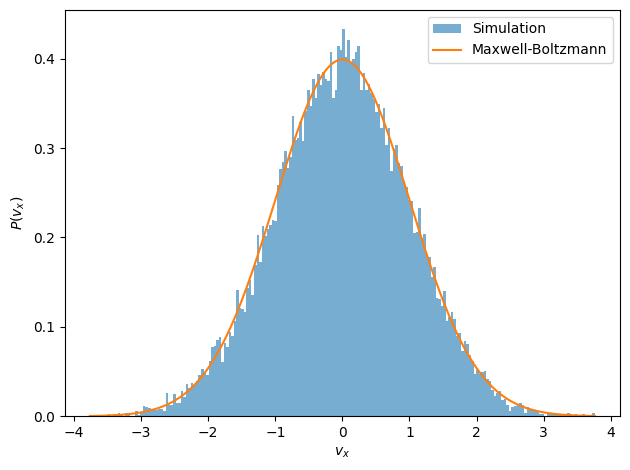

In [6]:
velocityDistr(system)

### Velocity Magnitude Distribution

In [7]:
def velocityMagnitudeDistr(system):

    v_abs = np.sqrt(np.sum(system.v**2, axis=1))

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(v_abs.min(), v_abs.max(), 300)

    pdf = (
        4*np.pi*(1/(2*np.pi*sigma)**(3.0/2))*x**2*np.exp(-x**2/(2*sigma))
    )
    # Since v_abs is a square, the actual values are roots
    plt.hist(v_abs, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

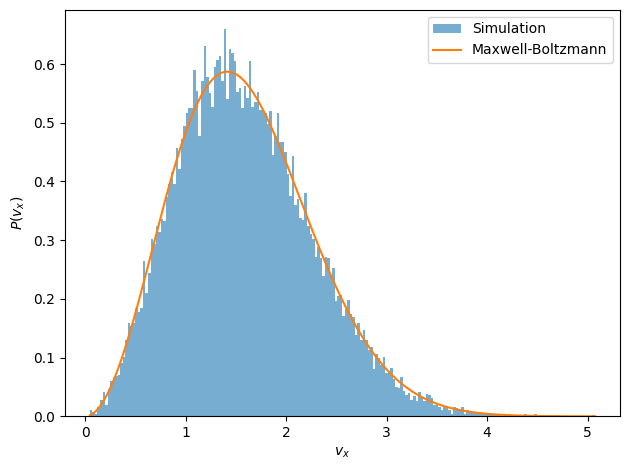

In [8]:
velocityMagnitudeDistr(system)

### Number of Particles in a Cell Distribution

In [9]:
def particlesInCellDistr(system):

    cells = distributeToCells(system.r, system.box, system.a)
    nInCell = np.array([len(cell) for cell in cells.flat])
    nMean = nInCell.mean()
    n_values = np.arange(0, nInCell.max() + 1)

    bin_edges = np.arange(
        nInCell.max() + 2
    ) - 0.5    

    plt.figure(figsize=(7, 4))
    plt.hist(
        nInCell,
        bins=bin_edges,
        density=True,
        alpha=0.6,
        label="Simulation"
    )
    plt.plot(
        n_values,
        poisson.pmf(n_values, nMean),
        "-",
        label=fr"Poisson, $\lambda={nMean:.2f}$"
    )

    plt.xlabel(r"Number of particles in a cell $N_c$")
    plt.ylabel(r"Probability $P(N_c)$")
    plt.title("Cell occupancy distribution")
    plt.legend()
    plt.tight_layout()

    plt.show()
    

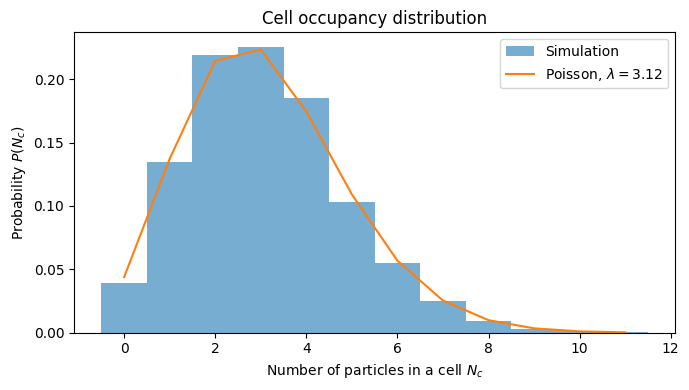

In [10]:
particlesInCellDistr(system)

### Non-uniform positions

In [11]:
def plot_density_profile_x(system, title):
    counts, edges = np.histogram(
        system.r[:, 0],
        bins=40,
        range=(0, system.box[0])
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.figure()
    plt.plot(centers, counts, marker="o")
    plt.xlabel("x")
    plt.ylabel("number of particles")
    plt.title(title)
    plt.show()

In [12]:
system.r[:, 0] = system.rng.uniform(0.0, system.box[0] / 2, size=system.N)
system.r[:, 1] = system.rng.uniform(0.0, system.box[1], size=system.N)
system.r[:, 2] = system.rng.uniform(0.0, system.box[2], size=system.N)

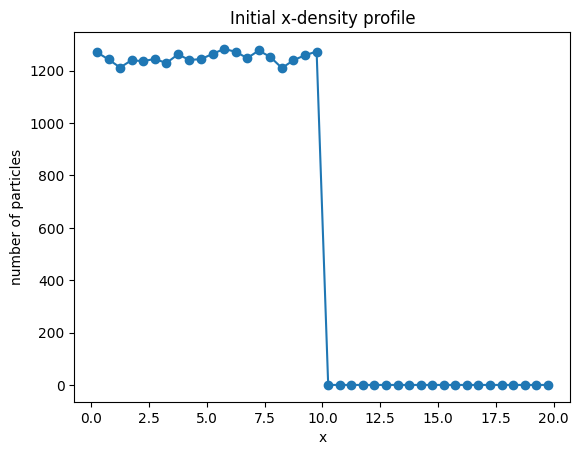

In [13]:
plot_density_profile_x(system, "Initial x-density profile")

In [14]:
energy = []
for i in range(50):
        stream(system)
        collide(system)
        energy.append(system_kinetic(system))



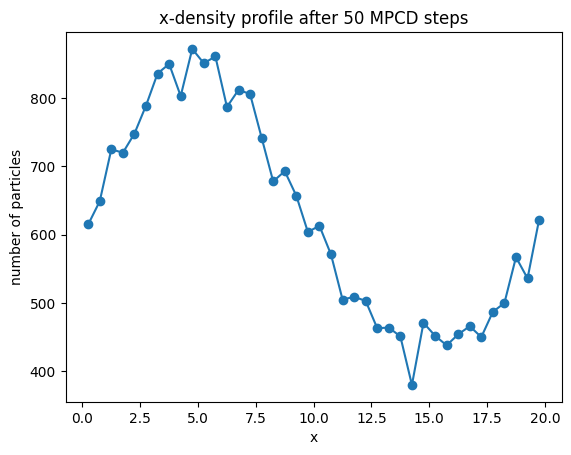

In [15]:
plot_density_profile_x(system, "x-density profile after 50 MPCD steps")

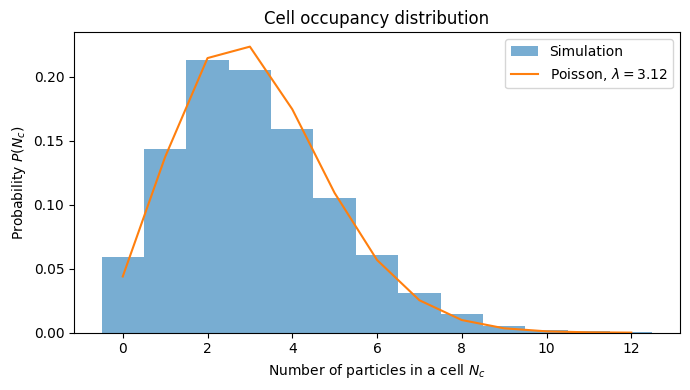

In [16]:
particlesInCellDistr(system)

In [17]:
for i in range(950):
        stream(system)
        collide(system)
        energy.append(system_kinetic(system))


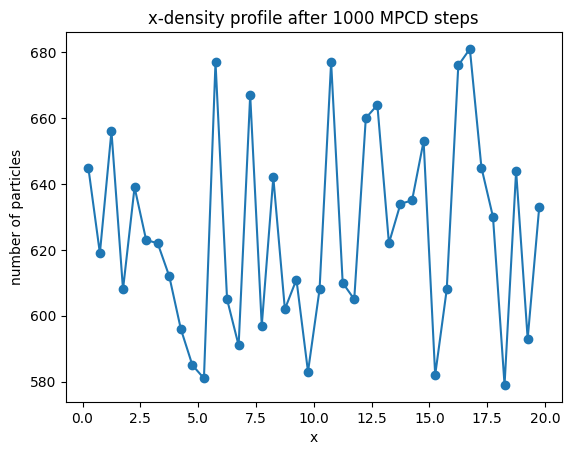

In [18]:
plot_density_profile_x(system, "x-density profile after 1000 MPCD steps")

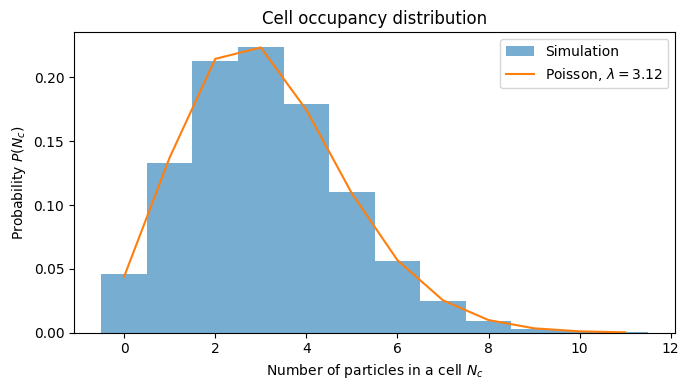

In [19]:
particlesInCellDistr(system)

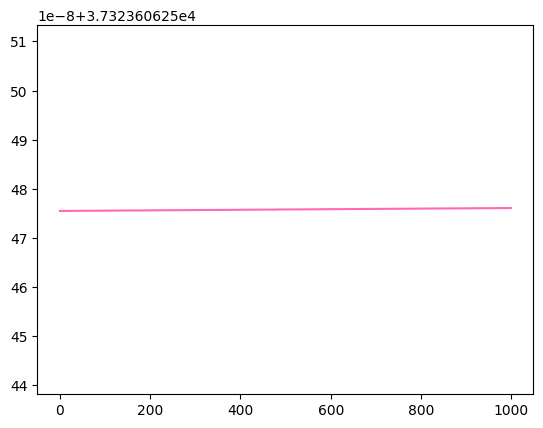

In [20]:
plt.figure()
plt.plot(energy, color="hotpink")
plt.show()

### Non normal velocities

In [21]:
def make_nonmaxwellian_velocities(system):

    directions = system.rng.normal(size=(system.N, 3))
    directions /= np.linalg.norm(directions, axis=1)[:, None]

    speed = np.sqrt(3* system.kBT / system.m)

    system.v = speed * directions

    # remove center-of-mass drift
    system.v -= system.v.mean(axis=0)

In [22]:
def plot_velocity_components(v, title):
    plt.figure()

    #plt.hist(v[:, 0], bins=60, density=True, alpha=0.5, label="vx")
    plt.hist(v[:, 1], bins=60, density=True, alpha=0.5, label="vy")
    #plt.hist(v[:, 2], bins=60, density=True, alpha=0.5, label="vz")

    plt.xlabel("velocity component")
    plt.ylabel("probability density")
    plt.title(title)
    plt.legend()
    plt.show()

In [23]:
make_nonmaxwellian_velocities(system)

In [24]:
v_initial = system.v.copy()
speeds_initial = np.linalg.norm(system.v, axis=1)

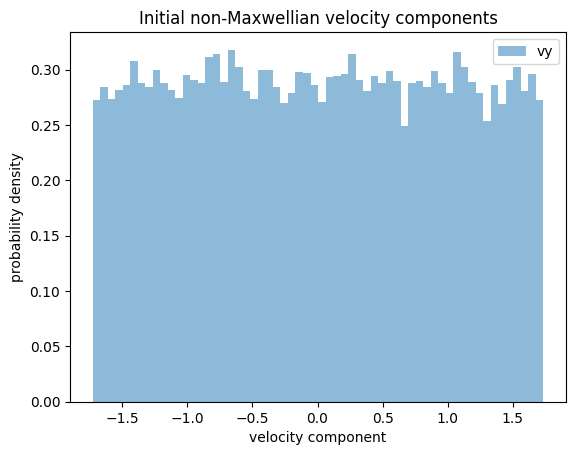

In [25]:
plot_velocity_components(v_initial, "Initial non-Maxwellian velocity components")

In [26]:
temperature=[]
for i in range(1000):
        stream(system)
        collide(system)
        temperature.append(solvent_temperature(system))

In [27]:
v_finish = system.v.copy()
speeds_finish = np.linalg.norm(system.v, axis=1)

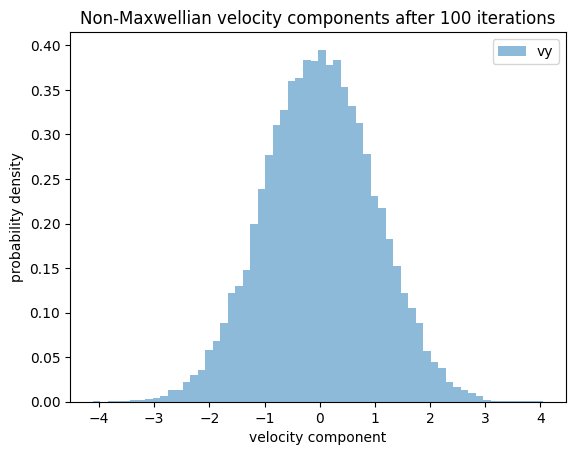

In [28]:
plot_velocity_components(v_finish, "Non-Maxwellian velocity components after 100 iterations")

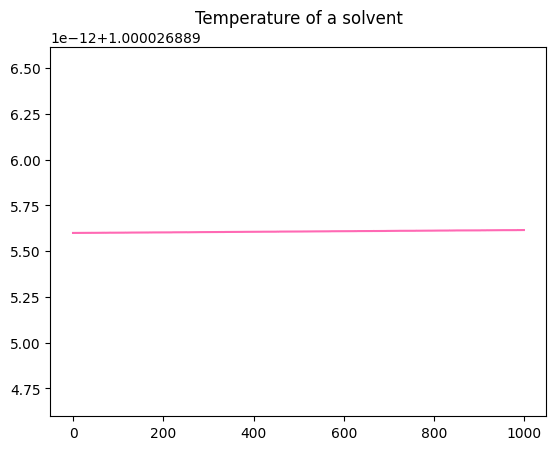

In [29]:
plt.figure()
plt.plot(temperature, color="hotpink")
plt.title("Temperature of a solvent")
plt.show()